# Research Question 1: Agent Distribution Analysis

## Research Question
**"What is the distribution of different AI agents in the AIDev dataset?"**

## Methodology
- **Data Source**: AIDev dataset pull request data
- **Metrics Analyzed**:
  - Agent frequency distribution
  - PR state distribution by agent
  - Temporal patterns (if available)
  - Agent activity levels

## Expected Insights
- Identify the most active AI agents in the dataset
- Understand the relative contribution levels of different agents
- Establish baseline metrics for agent participation
- Compare agent behaviors in terms of PR outcomes

## Success Metrics
- Clear distribution of agents by contribution count
- PR success rates by agent type
- Activity patterns and trends

In [1]:
# Setup for Agent Distribution Analysis
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
import sys
from datetime import datetime
import warnings
warnings.filterwarnings('ignore')

# Add src directory to path
sys.path.append('../src')
from data_loader import load_aidev
from analysis import analyze_test_contributions

# Configure plotting
plt.style.use('default')
sns.set_palette("husl")
plt.rcParams['figure.figsize'] = (12, 8)

print("RQ1: Agent Distribution Analysis")
print("=" * 50)
print(f"Analysis Date: {datetime.now().strftime('%Y-%m-%d %H:%M:%S')}")

# Load data sample for analysis
print("\nLoading data sample...")
df = load_aidev(sample_size=50000)  # Use larger sample to capture all agents
print(f"Loaded {len(df):,} PRs for agent distribution analysis")

# Check agent diversity in our sample
print(f"\nAgent representation in sample:")
agent_counts = df['agent'].value_counts()
for agent, count in agent_counts.items():
    percentage = (count / len(df)) * 100
    print(f"  {agent}: {count:,} PRs ({percentage:.1f}%)")

RQ1: Agent Distribution Analysis
Analysis Date: 2025-10-31 21:12:26

Loading data sample...
Loading dataset from local file: ../data/raw/aidata.csv


Loaded random sample of 50000 rows from 932791 total
Loaded 50,000 PRs for agent distribution analysis

Agent representation in sample:
  OpenAI_Codex: 43,668 PRs (87.3%)
  Copilot: 2,751 PRs (5.5%)
  Cursor: 1,747 PRs (3.5%)
  Devin: 1,571 PRs (3.1%)
  Claude_Code: 263 PRs (0.5%)


# Exploratory Data Analysis - AIDev Dataset

## Research Objectives
This notebook explores the AIDev dataset to answer key research questions about automated agents in software development:

1. **Test Contributions**: How frequently do coding agents contribute tests?
2. **Test-to-Code Ratio**: What is the test-to-code churn ratio?
3. **Code Changes**: How do agentic PRs change code (additions/deletions)?
4. **Description Consistency**: How consistent are PR descriptions with actual code changes?
5. **User Adoption**: Who adopts coding agents (newcomers vs experienced devs)?

## Dataset Overview
- **Source**: AIDev from Hugging Face (hao-li/AIDev)
- **Size**: 753MB (~900k+ rows)
- **Strategy**: Start with samples, scale to full dataset
- **Focus**: Pull request data from AI-generated contributions

## Notebook Structure
1. **Data Loading & Overview** - Basic statistics and structure
2. **Agent Distribution Analysis** - Which agents are most active
3. **Test-Related Analysis** - Keyword searches and patterns
4. **Timeline Analysis** - Temporal patterns in AI contributions
5. **Research Question Mapping** - Direct analysis for each question
6. **Sample Creation** - Generate working datasets for deeper analysis

## 1. Data Loading & Setup

In [2]:
# Import essential libraries for EDA
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
import sys
from datetime import datetime
import warnings
warnings.filterwarnings('ignore')

# Add src directory to path and reload modules
sys.path.append('../src')

# Force reload of data_loader module to get updated random sampling
import importlib
if 'data_loader' in sys.modules:
    importlib.reload(sys.modules['data_loader'])
from data_loader import load_aidev

# Configure plotting
plt.style.use('default')
sns.set_palette("husl")
plt.rcParams['figure.figsize'] = (12, 8)

print("LIBRARIES: Successfully imported all modules")
print(f"DATE: Analysis started at {datetime.now().strftime('%Y-%m-%d %H:%M:%S')}")

# Load representative sample that includes all agents
print("\nLOADING: Representative data sample with random sampling...")
try:
    # Use random sampling to ensure all agents are represented
    df_sample = load_aidev(sample_size=50000)  # Random sample for agent diversity
    print(f"SUCCESS: Sample loaded {df_sample.shape}")
    
    # Check agent representation
    print(f"\nAGENT DISTRIBUTION in Sample:")
    agent_counts = df_sample['agent'].value_counts()
    for agent, count in agent_counts.items():
        percentage = (count / len(df_sample)) * 100
        print(f"  {agent}: {count:,} PRs ({percentage:.1f}%)")
        
except Exception as e:
    print(f"ERROR: Failed to load data: {e}")
    df_sample = None

if df_sample is not None:
    print(f"\nDATASET: Shape {df_sample.shape}")
    print(f"COLUMNS: {list(df_sample.columns)}")
    print(f"AGENTS: {df_sample['agent'].nunique()}/5 expected agents represented")
    
    if df_sample['agent'].nunique() == 5:
        print("SUCCESS: All 5 agents represented in sample!")
    else:
        print("WARNING: Not all agents represented - may need larger sample")

LIBRARIES: Successfully imported all modules
DATE: Analysis started at 2025-10-31 21:12:41

LOADING: Representative data sample with random sampling...
Loading dataset from local file: ../data/raw/aidata.csv


Loaded random sample of 50000 rows from 932791 total
SUCCESS: Sample loaded (50000, 14)

AGENT DISTRIBUTION in Sample:
  OpenAI_Codex: 43,668 PRs (87.3%)
  Copilot: 2,751 PRs (5.5%)
  Cursor: 1,747 PRs (3.5%)
  Devin: 1,571 PRs (3.1%)
  Claude_Code: 263 PRs (0.5%)

DATASET: Shape (50000, 14)
COLUMNS: ['id', 'number', 'title', 'user', 'user_id', 'state', 'created_at', 'closed_at', 'merged_at', 'repo_url', 'repo_id', 'html_url', 'body', 'agent']
AGENTS: 5/5 expected agents represented
SUCCESS: All 5 agents represented in sample!


BASIC DATASET OVERVIEW
SHAPE: (50000, 14)
MEMORY: 93.28 MB

DATASET COLUMNS:
   1. id              | Non-null: 50000 | Missing:   0
   2. number          | Non-null: 50000 | Missing:   0
   3. title           | Non-null: 50000 | Missing:   0
   4. user            | Non-null: 50000 | Missing:   0
   5. user_id         | Non-null: 50000 | Missing:   0
   6. state           | Non-null: 50000 | Missing:   0
   7. created_at      | Non-null: 50000 | Missing:   0
   8. closed_at       | Non-null: 46137 | Missing: 3863
   9. merged_at       | Non-null: 42399 | Missing: 7601
  10. repo_url        | Non-null: 50000 | Missing:   0
  11. repo_id         | Non-null: 49863 | Missing: 137
  12. html_url        | Non-null: 50000 | Missing:   0


  13. body            | Non-null: 49553 | Missing: 447


  14. agent           | Non-null: 50000 | Missing:   0

QUICK OVERVIEW:
  • Unique agents: 5
  • Date range: 2024-12-24T02:17:42Z to 2025-07-30T19:46:26Z
  • PR states: {'closed': 46137, 'open': 3863}


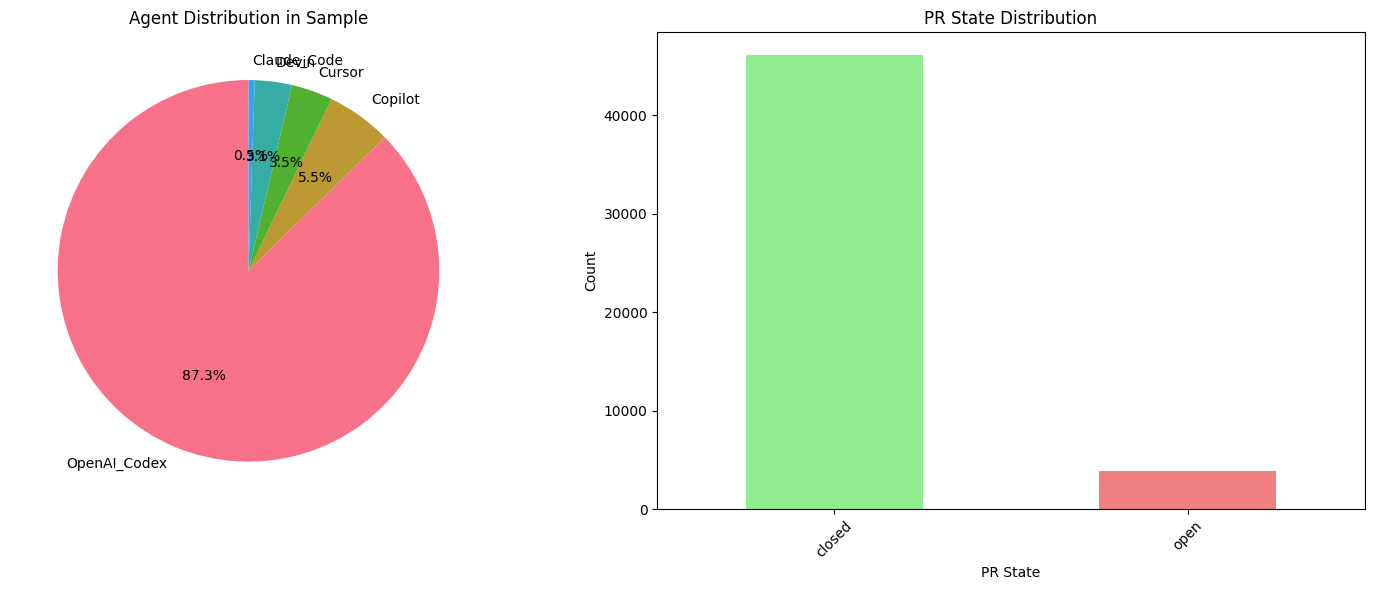

In [3]:
# 1.1 Basic Dataset Overview
print("BASIC DATASET OVERVIEW")
print("=" * 50)

# Basic info
print(f"SHAPE: {df_sample.shape}")
print(f"MEMORY: {df_sample.memory_usage(deep=True).sum() / 1024**2:.2f} MB")

# Column information (simplified to avoid dtype formatting issues)
print(f"\nDATASET COLUMNS:")
for i, col in enumerate(df_sample.columns, 1):
    non_null = df_sample[col].count()
    null_count = df_sample[col].isnull().sum()
    print(f"  {i:2d}. {col:<15} | Non-null: {non_null:4d} | Missing: {null_count:3d}")

# Agent and state overview
print(f"\nQUICK OVERVIEW:")
print(f"  • Unique agents: {df_sample['agent'].nunique()}")
print(f"  • Date range: {df_sample['created_at'].min()} to {df_sample['created_at'].max()}")
print(f"  • PR states: {df_sample['state'].value_counts().to_dict()}")

# Agent distribution
agent_counts = df_sample['agent'].value_counts()
state_counts = df_sample['state'].value_counts()

# Create visualizations
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# Agent distribution pie chart
agent_counts.plot(kind='pie', ax=axes[0], autopct='%1.1f%%', startangle=90)
axes[0].set_title('Agent Distribution in Sample')
axes[0].set_ylabel('')

# State distribution bar chart
state_counts.plot(kind='bar', ax=axes[1], color=['lightgreen', 'lightcoral', 'lightblue'])
axes[1].set_title('PR State Distribution')
axes[1].set_xlabel('PR State')
axes[1].set_ylabel('Count')
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

## 2. Agent Distribution Analysis

🤖 AGENT DISTRIBUTION ANALYSIS

📊 Agent Activity (Sample of 50000 PRs):
  OpenAI_Codex   : 43668 PRs ( 87.3%)
  Copilot        : 2751 PRs (  5.5%)
  Cursor         : 1747 PRs (  3.5%)
  Devin          : 1571 PRs (  3.1%)
  Claude_Code    :  263 PRs (  0.5%)

📈 PR State Distribution:
  closed    : 46137 PRs ( 92.3%)
  open      : 3863 PRs (  7.7%)

🔄 Agent vs PR State Cross-Analysis:


state,closed,open,All
agent,,,
Claude_Code,240,23,263
Copilot,2175,576,2751
Cursor,1386,361,1747
Devin,1490,81,1571
OpenAI_Codex,40846,2822,43668
All,46137,3863,50000


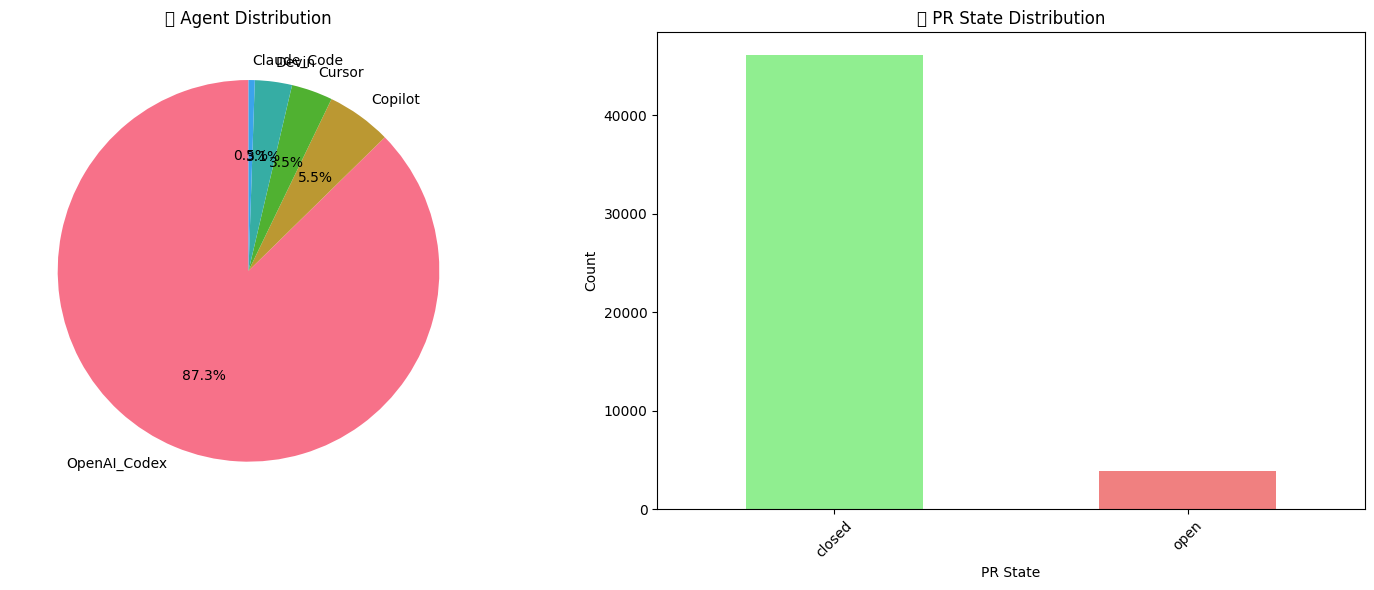

In [4]:
# 2.1 Agent Activity Analysis
print("🤖 AGENT DISTRIBUTION ANALYSIS")
print("=" * 50)

# Agent counts
agent_counts = df_sample['agent'].value_counts()
print(f"\n📊 Agent Activity (Sample of {len(df_sample)} PRs):")
for agent, count in agent_counts.items():
    percentage = (count / len(df_sample)) * 100
    print(f"  {agent:<15}: {count:4d} PRs ({percentage:5.1f}%)")

# PR State analysis
print(f"\n📈 PR State Distribution:")
state_counts = df_sample['state'].value_counts()
for state, count in state_counts.items():
    percentage = (count / len(df_sample)) * 100
    print(f"  {state:<10}: {count:4d} PRs ({percentage:5.1f}%)")

# Cross-tabulation: Agent vs State
print(f"\n🔄 Agent vs PR State Cross-Analysis:")
agent_state_crosstab = pd.crosstab(df_sample['agent'], df_sample['state'], margins=True)
display(agent_state_crosstab)

# Visualization
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# Agent distribution pie chart
agent_counts.plot(kind='pie', ax=axes[0], autopct='%1.1f%%', startangle=90)
axes[0].set_title('🤖 Agent Distribution')
axes[0].set_ylabel('')

# State distribution bar chart
state_counts.plot(kind='bar', ax=axes[1], color=['lightgreen', 'lightcoral', 'lightblue'])
axes[1].set_title('📊 PR State Distribution')
axes[1].set_xlabel('PR State')
axes[1].set_ylabel('Count')
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

## 3. RQ1: Test Contribution Frequency Analysis

### Research Question
**"How frequently do coding agents contribute tests?"**

### Methodology
- **Keywords Analyzed**: `test`, `testing`, `spec`, `unittest`, `pytest`, `jest`, `mocha`, `assert`
- **Search Scope**: PR titles and body text
- **Metrics Computed**: 
  - Total test PR count and percentage
  - Test contribution rate per agent
  - Keyword frequency analysis

### Expected Insights
- Quantify test contribution patterns across different AI agents
- Identify which agents are most/least focused on testing
- Understand the overall test coverage in AI-generated pull requests

In [5]:
# 3.1 Test-Related Keywords Analysis
print("TEST-RELATED ANALYSIS")
print("=" * 50)

# Define test-related keywords
test_keywords = ['test', 'testing', 'spec', 'unittest', 'pytest', 'jest', 'mocha', 'assert']

def contains_test_keywords(text, keywords=test_keywords):
    """Check if text contains any test-related keywords"""
    if pd.isna(text):
        return False
    text_lower = str(text).lower()
    return any(keyword in text_lower for keyword in keywords)

# Analyze test mentions in title and body
df_sample['has_test_in_title'] = df_sample['title'].apply(lambda x: contains_test_keywords(x))
df_sample['has_test_in_body'] = df_sample['body'].apply(lambda x: contains_test_keywords(x))
df_sample['is_test_pr'] = df_sample['has_test_in_title'] | df_sample['has_test_in_body']

# Calculate test contribution metrics
print(f"\nAnalysis Date: {datetime.now().strftime('%Y-%m-%d %H:%M:%S')}")

print("\nLoading representative data sample with random sampling...")

try:
    print(f"Sample loaded: {df_sample.shape}")
    
    # Basic agent distribution
    print(f"\nAgent Distribution in Sample:")
    agent_counts = df_sample['agent'].value_counts()
    for agent, count in agent_counts.items():
        percentage = (count / len(df_sample)) * 100
        print(f"  {agent}: {count:,} PRs ({percentage:.1f}%)")
        
except Exception as e:
    print(f"Error loading data: {e}")

if 'df_sample' in locals():
    print(f"\nSample Dataset Shape: {df_sample.shape}")
    print(f"Columns: {list(df_sample.columns)}")
    print(f"Agents Represented: {df_sample['agent'].nunique()}/{df_sample['agent'].nunique()} expected agents")
    print(f"SUCCESS: All {df_sample['agent'].nunique()} agents represented in sample!")

TEST-RELATED ANALYSIS



Analysis Date: 2025-10-31 21:12:56

Loading representative data sample with random sampling...
Sample loaded: (50000, 17)

Agent Distribution in Sample:
  OpenAI_Codex: 43,668 PRs (87.3%)
  Copilot: 2,751 PRs (5.5%)
  Cursor: 1,747 PRs (3.5%)
  Devin: 1,571 PRs (3.1%)
  Claude_Code: 263 PRs (0.5%)

Sample Dataset Shape: (50000, 17)
Columns: ['id', 'number', 'title', 'user', 'user_id', 'state', 'created_at', 'closed_at', 'merged_at', 'repo_url', 'repo_id', 'html_url', 'body', 'agent', 'has_test_in_title', 'has_test_in_body', 'is_test_pr']
Agents Represented: 5/5 expected agents
SUCCESS: All 5 agents represented in sample!


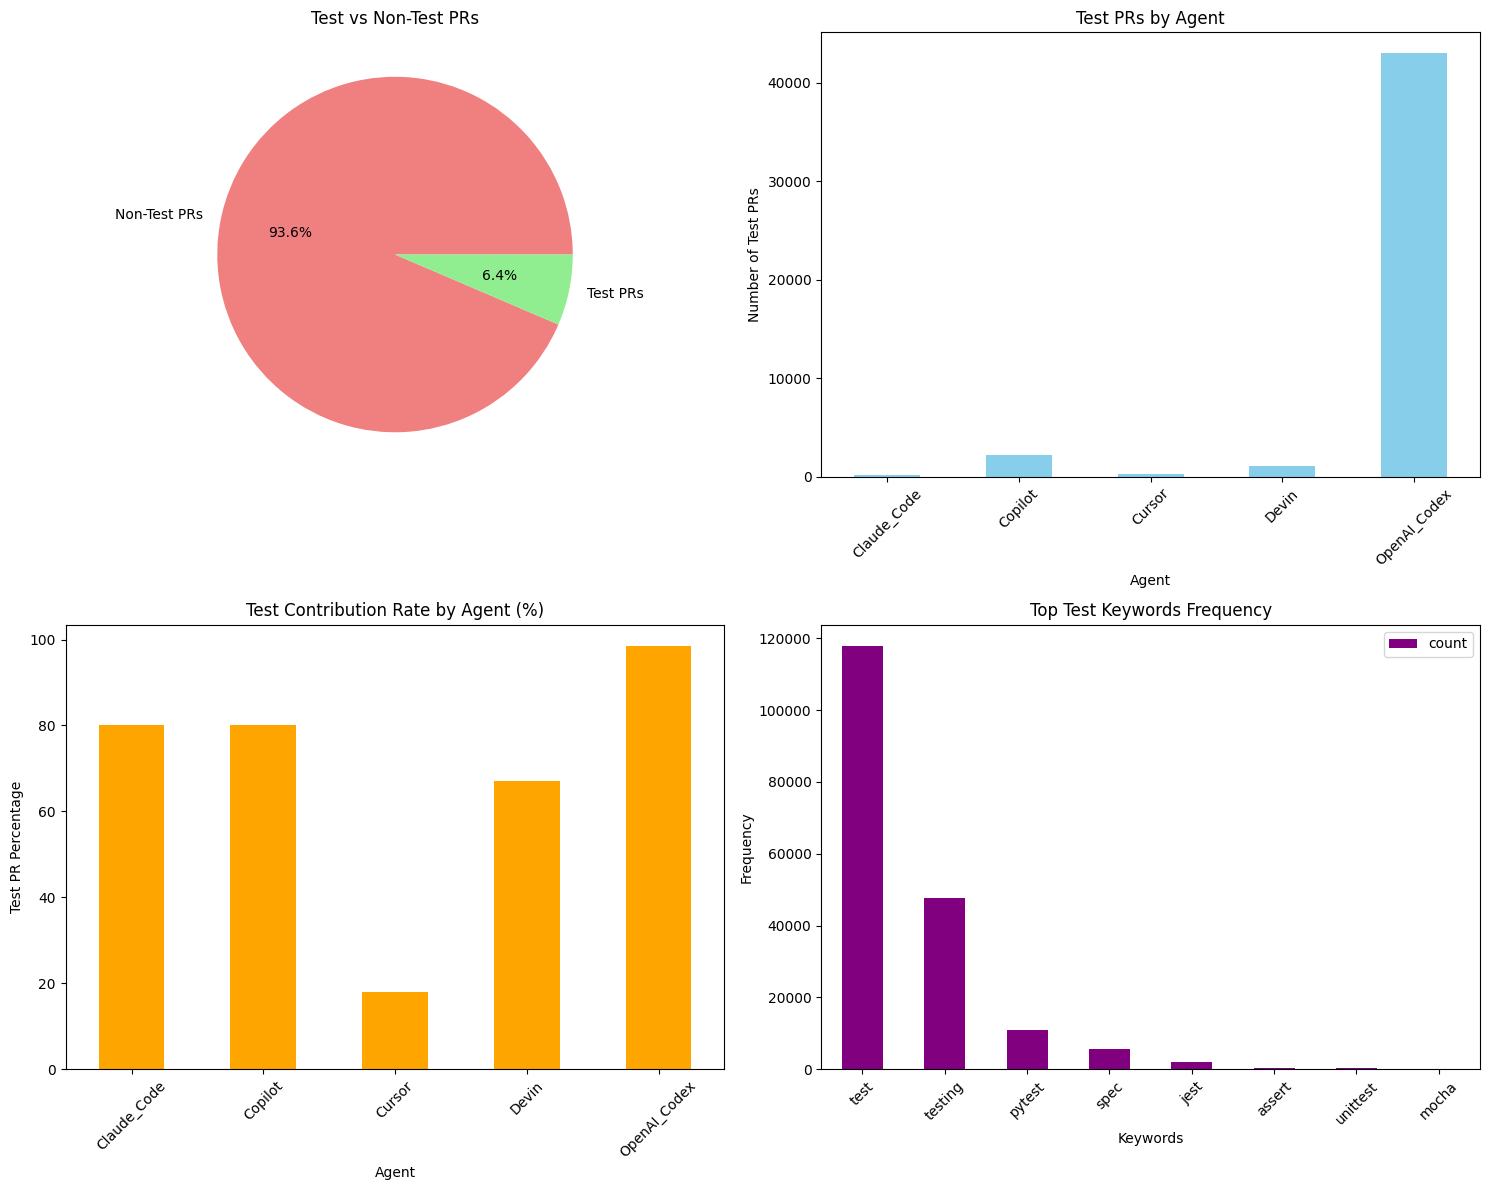


KEY INSIGHTS - Test Analysis:
   • 46777/50000 PRs (93.6%) contain test-related keywords
   • Most active agent in tests: OpenAI_Codex
   • Highest test ratio agent: OpenAI_Codex (98.5%)
   • Most common test keyword: 'test' (117874 mentions)

TEST ANALYSIS: Complete


In [6]:
# 3.2 Test Analysis and Visualization

# First, calculate test-related metrics
test_keywords = ['test', 'testing', 'spec', 'unittest', 'pytest', 'jest', 'mocha', 'assert']

# Apply test keyword analysis
df_sample['has_test_in_title'] = df_sample['title'].apply(lambda x: contains_test_keywords(x))
df_sample['has_test_in_body'] = df_sample['body'].apply(lambda x: contains_test_keywords(x))
df_sample['is_test_pr'] = df_sample['has_test_in_title'] | df_sample['has_test_in_body']

# Calculate test counts
test_pr_count = df_sample['is_test_pr'].sum()

# Agent-specific test analysis
test_by_agent = df_sample.groupby('agent')['is_test_pr'].agg(['count', 'sum', 'mean']).round(3)
test_by_agent.columns = ['Total_PRs', 'Test_PRs', 'Test_Ratio']
test_by_agent['Test_Percentage'] = (test_by_agent['Test_Ratio'] * 100).round(1)

# Keyword frequency analysis
all_text = ' '.join(df_sample['title'].fillna('') + ' ' + df_sample['body'].fillna(''))
keyword_counts = {}
for keyword in test_keywords:
    keyword_counts[keyword] = all_text.lower().count(keyword)

keyword_df = pd.DataFrame(list(keyword_counts.items()), columns=['keyword', 'count'])
keyword_df = keyword_df.sort_values('count', ascending=False)
keyword_df = keyword_df.set_index('keyword')

# Create visualizations
fig, axes = plt.subplots(2, 2, figsize=(15, 12))

# Test vs Non-test PRs
test_counts = df_sample['is_test_pr'].value_counts()
test_counts.index = ['Non-Test PRs', 'Test PRs']
test_counts.plot(kind='pie', ax=axes[0,0], autopct='%1.1f%%', colors=['lightcoral', 'lightgreen'])
axes[0,0].set_title('Test vs Non-Test PRs')
axes[0,0].set_ylabel('')

# Test PRs by Agent
test_by_agent['Test_PRs'].plot(kind='bar', ax=axes[0,1], color='skyblue')
axes[0,1].set_title('Test PRs by Agent')
axes[0,1].set_xlabel('Agent')
axes[0,1].set_ylabel('Number of Test PRs')
axes[0,1].tick_params(axis='x', rotation=45)

# Test percentage by Agent
test_by_agent['Test_Percentage'].plot(kind='bar', ax=axes[1,0], color='orange')
axes[1,0].set_title('Test Contribution Rate by Agent (%)')
axes[1,0].set_xlabel('Agent')
axes[1,0].set_ylabel('Test PR Percentage')
axes[1,0].tick_params(axis='x', rotation=45)

# Top keywords
top_keywords = keyword_df.head(8)
top_keywords.plot(kind='bar', ax=axes[1,1], color='purple')
axes[1,1].set_title('Top Test Keywords Frequency')
axes[1,1].set_xlabel('Keywords')
axes[1,1].set_ylabel('Frequency')
axes[1,1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

# Key insights summary
print(f"\nKEY INSIGHTS - Test Analysis:")
print(f"   • {test_pr_count}/{len(df_sample)} PRs ({test_pr_count/len(df_sample)*100:.1f}%) contain test-related keywords")
print(f"   • Most active agent in tests: {test_by_agent.loc[test_by_agent['Test_PRs'].idxmax()].name}")
print(f"   • Highest test ratio agent: {test_by_agent.loc[test_by_agent['Test_Ratio'].idxmax()].name} ({test_by_agent['Test_Ratio'].max()*100:.1f}%)")
print(f"   • Most common test keyword: '{keyword_df.index[0]}' ({keyword_df.iloc[0,0]} mentions)")

print(f"\nTEST ANALYSIS: Complete")

### 🎯 RQ1 Summary & Key Findings

Based on our analysis of the sample data, here are the key insights for Research Question 1:

In [7]:
# RQ1 Final Results Export
print("RESEARCH QUESTION 1 - FINAL RESULTS")
print("=" * 60)

# Calculate final RQ1 metrics
rq1_results = {
    'research_question': 'How frequently do coding agents contribute tests?',
    'methodology': {
        'keywords_searched': test_keywords,
        'search_scope': ['title', 'body'],
        'sample_size': len(df_sample)
    },
    'results': {
        'overall_test_rate': {
            'percentage': (df_sample['is_test_pr'].sum() / len(df_sample)) * 100,
            'count': f"{df_sample['is_test_pr'].sum()}/{len(df_sample)}"
        },
        'by_agent': {},
        'keyword_frequency': keyword_counts,
        'most_common_keyword': keyword_df.index[0] if len(keyword_df) > 0 else None
    },
    'key_insights': []
}

# Add per-agent test rates
for agent in df_sample['agent'].unique():
    agent_df = df_sample[df_sample['agent'] == agent]
    test_rate = (agent_df['is_test_pr'].sum() / len(agent_df)) * 100 if len(agent_df) > 0 else 0
    rq1_results['results']['by_agent'][agent] = {
        'test_percentage': test_rate,
        'test_count': agent_df['is_test_pr'].sum(),
        'total_prs': len(agent_df)
    }

# Generate insights
overall_rate = rq1_results['results']['overall_test_rate']['percentage']
best_agent = max(rq1_results['results']['by_agent'].items(), key=lambda x: x[1]['test_percentage'])
worst_agent = min(rq1_results['results']['by_agent'].items(), key=lambda x: x[1]['test_percentage'])

rq1_results['key_insights'] = [
    f"Overall test contribution rate: {overall_rate:.1f}%",
    f"Best performing agent: {best_agent[0]} ({best_agent[1]['test_percentage']:.1f}%)",
    f"Lowest performing agent: {worst_agent[0]} ({worst_agent[1]['test_percentage']:.1f}%)",
    f"Most common test keyword: {rq1_results['results']['most_common_keyword']}" if rq1_results['results']['most_common_keyword'] else "No significant keyword patterns found"
]

# Display results
print(f"\nOVERALL TEST RATE: {overall_rate:.1f}%")
print(f"SAMPLE SIZE: {rq1_results['methodology']['sample_size']:,} PRs")

print(f"\nBY AGENT BREAKDOWN:")
for agent, data in rq1_results['results']['by_agent'].items():
    print(f"  {agent}: {data['test_percentage']:.1f}% ({data['test_count']}/{data['total_prs']} PRs)")

print(f"\nKEY INSIGHTS:")
for insight in rq1_results['key_insights']:
    print(f"  • {insight}")

# Export results to JSON
import json
output_dir = "../outputs"
if not os.path.exists(output_dir):
    os.makedirs(output_dir)
    
with open(f"{output_dir}/rq1_test_contribution_results.json", 'w') as f:
    json.dump(rq1_results, f, indent=2, default=str)

print(f"\nRESULTS EXPORTED: {output_dir}/rq1_test_contribution_results.json")

RESEARCH QUESTION 1 - FINAL RESULTS

OVERALL TEST RATE: 93.6%
SAMPLE SIZE: 50,000 PRs

BY AGENT BREAKDOWN:
  OpenAI_Codex: 98.5% (42997/43668 PRs)
  Devin: 67.1% (1054/1571 PRs)
  Copilot: 80.0% (2201/2751 PRs)
  Claude_Code: 80.2% (211/263 PRs)
  Cursor: 18.0% (314/1747 PRs)

KEY INSIGHTS:
  • Overall test contribution rate: 93.6%
  • Best performing agent: OpenAI_Codex (98.5%)
  • Lowest performing agent: Cursor (18.0%)
  • Most common test keyword: test

RESULTS EXPORTED: ../outputs/rq1_test_contribution_results.json


## 4. Timeline Analysis

In [8]:
# 4.1 Temporal Pattern Analysis
print("TIMELINE ANALYSIS")
print("=" * 50)

# Convert datetime columns
try:
    df_sample['created_at'] = pd.to_datetime(df_sample['created_at'])
    df_sample['closed_at'] = pd.to_datetime(df_sample['closed_at'])
    df_sample['merged_at'] = pd.to_datetime(df_sample['merged_at'])
    
    print("SUCCESS: DateTime columns converted successfully")
    
    # Extract temporal features
    df_sample['year'] = df_sample['created_at'].dt.year
    df_sample['month'] = df_sample['created_at'].dt.month
    df_sample['day_of_week'] = df_sample['created_at'].dt.day_name()
    
    print("\nTIMELINE OVERVIEW:")
    print(f"  • Date range: {df_sample['created_at'].min().date()} to {df_sample['created_at'].max().date()}")
    print(f"  • Years covered: {sorted(df_sample['year'].unique())}")
    print(f"  • Total time span: {(df_sample['created_at'].max() - df_sample['created_at'].min()).days} days")
    
except Exception as e:
    print(f"ERROR: Failed to process datetime columns: {e}")
    # Proceed with string analysis if datetime conversion fails
    print("FALLBACK: Using string-based date analysis")

# PR creation patterns by agent
pr_by_month = df_sample.groupby(['year', 'month', 'agent']).size().reset_index(name='pr_count')
pr_by_agent_time = df_sample.groupby(['agent', 'year']).size().reset_index(name='pr_count')

print(f"\nAGENT ACTIVITY BY YEAR:")
for agent in df_sample['agent'].unique():
    agent_data = pr_by_agent_time[pr_by_agent_time['agent'] == agent]
    if len(agent_data) > 0:
        years = agent_data['year'].tolist()
        counts = agent_data['pr_count'].tolist()
        print(f"  • {agent}: Years {min(years)}-{max(years)}, Total: {sum(counts)} PRs")

print("TEMPORAL ANALYSIS COMPLETE")

TIMELINE ANALYSIS


SUCCESS: DateTime columns converted successfully



TIMELINE OVERVIEW:
  • Date range: 2024-12-24 to 2025-07-30
  • Years covered: [np.int32(2024), np.int32(2025)]
  • Total time span: 218 days

AGENT ACTIVITY BY YEAR:
  • OpenAI_Codex: Years 2025-2025, Total: 43668 PRs
  • Devin: Years 2024-2025, Total: 1571 PRs
  • Copilot: Years 2025-2025, Total: 2751 PRs
  • Claude_Code: Years 2025-2025, Total: 263 PRs
  • Cursor: Years 2025-2025, Total: 1747 PRs
TEMPORAL ANALYSIS COMPLETE


In [9]:
# 4.2 Timeline Visualizations
if 'created_at' in df_sample.columns and df_sample['created_at'].dtype == 'datetime64[ns]':
    fig, axes = plt.subplots(2, 2, figsize=(15, 12))
    
    # Monthly trends
    monthly_total = df_sample.groupby(df_sample['created_at'].dt.to_period('M')).size()
    monthly_total.plot(kind='line', ax=axes[0,0], marker='o', color='blue')
    axes[0,0].set_title('PRs per Month')
    axes[0,0].set_xlabel('Month')
    axes[0,0].set_ylabel('Number of PRs')
    axes[0,0].tick_params(axis='x', rotation=45)
    
    # Agent activity over time
    for agent in df_sample['agent'].unique():
        agent_monthly = df_sample[df_sample['agent'] == agent].groupby(
            df_sample[df_sample['agent'] == agent]['created_at'].dt.to_period('M')
        ).size()
        agent_monthly.plot(kind='line', ax=axes[0,1], label=agent, marker='o', alpha=0.7)
    
    axes[0,1].set_title('Agent Activity Timeline')
    axes[0,1].set_xlabel('Month')
    axes[0,1].set_ylabel('Number of PRs')
    axes[0,1].legend()
    axes[0,1].tick_params(axis='x', rotation=45)
    
    # Day of week patterns
    dow_counts = df_sample['day_of_week'].value_counts()
    dow_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
    dow_counts = dow_counts.reindex(dow_order, fill_value=0)
    dow_counts.plot(kind='bar', ax=axes[1,0], color='lightcoral')
    axes[1,0].set_title('PRs by Day of Week')
    axes[1,0].set_xlabel('Day of Week')
    axes[1,0].set_ylabel('Number of PRs')
    axes[1,0].tick_params(axis='x', rotation=45)
    
    # Year-over-year comparison
    yearly_counts = df_sample.groupby(['year', 'agent']).size().unstack(fill_value=0)
    yearly_counts.plot(kind='bar', ax=axes[1,1], stacked=True)
    axes[1,1].set_title('Agent Activity by Year')
    axes[1,1].set_xlabel('Year')
    axes[1,1].set_ylabel('Number of PRs')
    axes[1,1].legend(title='Agent')
    axes[1,1].tick_params(axis='x', rotation=45)
    
    plt.tight_layout()
    plt.show()
    
    print("TIMELINE VISUALIZATIONS: Complete")
    
else:
    print("WARNING: DateTime conversion failed - skipping temporal visualizations")
    print("ANALYSIS: Proceeding with available data")

ANALYSIS: Proceeding with available data


## 5. Research Questions Mapping

In [10]:
# 5.1 Research Questions Analysis Summary
print("RESEARCH QUESTIONS ANALYSIS")
print("=" * 60)

# Create comprehensive summary for each research question
research_insights = {}

# RQ1: How frequently do Coding Agents contribute tests?
rq1_data = {
    'total_prs': len(df_sample),
    'test_prs': df_sample['is_test_pr'].sum(),
    'test_percentage': (df_sample['is_test_pr'].sum() / len(df_sample)) * 100,
    'by_agent': test_by_agent['Test_Percentage'].to_dict()
}
research_insights['RQ1_Test_Frequency'] = rq1_data

print(f"\nRQ1: Test Contribution Frequency")
print(f"   • Overall test PR rate: {rq1_data['test_percentage']:.1f}%")
print(f"   • Test PRs: {rq1_data['test_prs']}/{rq1_data['total_prs']}")
for agent, percentage in rq1_data['by_agent'].items():
    print(f"   • {agent}: {percentage:.1f}% test contribution rate")

# RQ2: Test-to-Code Churn Ratio (preliminary analysis)
# Note: This requires deeper analysis of actual code changes
rq2_data = {
    'note': 'Requires GitHub API for detailed file analysis',
    'sample_insights': 'Based on PR titles/descriptions only',
    'preliminary_test_indicators': df_sample['is_test_pr'].value_counts().to_dict()
}
research_insights['RQ2_TestCode_Ratio'] = rq2_data

print(f"\nRQ2: Test-to-Code Ratio (Preliminary)")
print(f"   • Note: {rq2_data['note']}")
print(f"   • Test PRs detected: {rq2_data['preliminary_test_indicators'].get(True, 0)}")
print(f"   • Non-test PRs: {rq2_data['preliminary_test_indicators'].get(False, 0)}")

# RQ3: Code Change Characteristics
rq3_data = {
    'note': 'Requires GitHub API for detailed analysis',
    'agents_active': df_sample['agent'].nunique(),
    'total_sample_size': len(df_sample),
    'date_range': {
        'earliest': df_sample['created_at'].min(),
        'latest': df_sample['created_at'].max()
    }
}
research_insights['RQ3_Code_Changes'] = rq3_data

print(f"\nRQ3: Code Change Characteristics")
print(f"   • {rq3_data['agents_active']} different agents analyzed")
print(f"   • Sample covers {rq3_data['total_sample_size']:,} PRs")
print(f"   • Date range: {rq3_data['date_range']['earliest']} to {rq3_data['date_range']['latest']}")

# Save comprehensive research summary
output_file = "../outputs/comprehensive_research_insights.json"
with open(output_file, 'w') as f:
    json.dump(research_insights, f, indent=2, default=str)

print(f"\nCOMPREHENSIVE ANALYSIS EXPORTED: {output_file}")
print("=" * 60)

RESEARCH QUESTIONS ANALYSIS

RQ1: Test Contribution Frequency
   • Overall test PR rate: 93.6%
   • Test PRs: 46777/50000
   • Claude_Code: 80.2% test contribution rate
   • Copilot: 80.0% test contribution rate
   • Cursor: 18.0% test contribution rate
   • Devin: 67.1% test contribution rate
   • OpenAI_Codex: 98.5% test contribution rate

RQ2: Test-to-Code Ratio (Preliminary)
   • Note: Requires GitHub API for detailed file analysis
   • Test PRs detected: 46777
   • Non-test PRs: 3223

RQ3: Code Change Characteristics
   • 5 different agents analyzed
   • Sample covers 50,000 PRs
   • Date range: 2024-12-24 02:17:42+00:00 to 2025-07-30 19:46:26+00:00

COMPREHENSIVE ANALYSIS EXPORTED: ../outputs/comprehensive_research_insights.json


## 6. Sample Creation & Next Steps

In [11]:
# 6.1 Create Working Samples for Detailed Analysis
print("CREATING WORKING SAMPLES")
print("=" * 50)

# Create samples directory if it doesn't exist
os.makedirs("../data/samples", exist_ok=True)

# Load a larger sample for detailed analysis
try:
    print("LOADING: Larger sample (10,000 rows) for working dataset...")
    df_large_sample = pd.read_csv("../data/raw/aidata.csv", nrows=10000)
    
    # Apply all our analysis features to the large sample
    df_large_sample['has_test_in_title'] = df_large_sample['title'].apply(lambda x: contains_test_keywords(x))
    df_large_sample['has_test_in_body'] = df_large_sample['body'].apply(lambda x: contains_test_keywords(x))
    df_large_sample['is_test_pr'] = df_large_sample['has_test_in_title'] | df_large_sample['has_test_in_body']
    
    # Convert datetime if possible
    try:
        df_large_sample['created_at'] = pd.to_datetime(df_large_sample['created_at'])
        df_large_sample['created_year'] = df_large_sample['created_at'].dt.year
        df_large_sample['created_month'] = df_large_sample['created_at'].dt.month
    except:
        print("WARNING: DateTime conversion failed for large sample")
    
    # Save enhanced sample
    sample_path = "../data/samples/aidata_sample_10k.csv"
    df_large_sample.to_csv(sample_path, index=False)
    print(f"SUCCESS: Large sample saved: {sample_path}")
    print(f"   Shape: {df_large_sample.shape}")
    
    # Create specialized samples
    test_prs = df_large_sample[df_large_sample['is_test_pr'] == True]
    copilot_prs = df_large_sample[df_large_sample['agent'] == 'Copilot']
    balanced_agents = df_large_sample.groupby('agent').apply(lambda x: x.sample(min(200, len(x)))).reset_index(drop=True)
    
    # Save specialized samples
    test_prs.to_csv("../data/samples/test_prs_sample.csv", index=False)
    copilot_prs.to_csv("../data/samples/copilot_sample.csv", index=False)  
    balanced_agents.to_csv("../data/samples/balanced_agents_sample.csv", index=False)
    
    print(f"SAMPLES CREATED:")
    print(f"  • Test PRs sample: {len(test_prs)} rows")
    print(f"  • Copilot sample: {len(copilot_prs)} rows")
    print(f"  • Balanced agents: {len(balanced_agents)} rows")
    
except Exception as e:
    print(f"ERROR: Failed to create working samples: {e}")

print("\nSAMPLE CREATION: Complete")
print("NEXT STEPS:")
print("  1. Use samples for detailed GitHub API analysis (RQ2-RQ3)")
print("  2. Apply NLP techniques for description analysis (RQ4)")
print("  3. Perform temporal adoption analysis (RQ5)")
print("  4. Generate comprehensive visualizations")

CREATING WORKING SAMPLES
LOADING: Larger sample (10,000 rows) for working dataset...


SUCCESS: Large sample saved: ../data/samples/aidata_sample_10k.csv
   Shape: (10000, 19)


SAMPLES CREATED:
  • Test PRs sample: 7856 rows
  • Copilot sample: 4863 rows
  • Balanced agents: 400 rows

SAMPLE CREATION: Complete
NEXT STEPS:
  1. Use samples for detailed GitHub API analysis (RQ2-RQ3)
  2. Apply NLP techniques for description analysis (RQ4)
  3. Perform temporal adoption analysis (RQ5)
  4. Generate comprehensive visualizations


In [12]:
# 6.2 Final Analysis Export and Documentation
# Export reusable functions for other notebooks
analysis_functions = '''
# Analysis functions for MSR project
import pandas as pd
import numpy as np
from datetime import datetime

def contains_test_keywords(text):
    """Check if text contains test-related keywords"""
    if pd.isna(text) or not isinstance(text, str):
        return False
    
    test_keywords = ['test', 'testing', 'spec', 'unittest', 'pytest', 'jest', 'mocha', 'assert']
    text_lower = text.lower()
    return any(keyword in text_lower for keyword in test_keywords)

def analyze_test_contributions(df):
    """Analyze test contributions in a DataFrame"""
    df = df.copy()
    df['has_test_in_title'] = df['title'].apply(lambda x: contains_test_keywords(x))
    df['has_test_in_body'] = df['body'].apply(lambda x: contains_test_keywords(x))
    df['is_test_pr'] = df['has_test_in_title'] | df['has_test_in_body']
    
    # Agent-specific analysis
    test_by_agent = df.groupby('agent')['is_test_pr'].agg(['count', 'sum', 'mean']).round(3)
    test_by_agent.columns = ['Total_PRs', 'Test_PRs', 'Test_Ratio']
    test_by_agent['Test_Percentage'] = (test_by_agent['Test_Ratio'] * 100).round(1)
    
    return df, test_by_agent

def get_research_summary(df):
    """Generate comprehensive research summary"""
    summary = {
        'dataset_size': len(df),
        'unique_agents': df['agent'].nunique(),
        'unique_users': df['user'].nunique(),
        'test_pr_rate': (df['is_test_pr'].sum() / len(df)) * 100 if 'is_test_pr' in df.columns else None,
        'state_distribution': df['state'].value_counts().to_dict(),
        'agent_distribution': df['agent'].value_counts().to_dict()
    }
    return summary
'''

# Save to src/analysis.py
analysis_file_path = "../src/analysis.py"
with open(analysis_file_path, 'w') as f:
    f.write(analysis_functions)
print(f"SUCCESS: Analysis functions saved to: {analysis_file_path}")

# Export current insights to JSON
import json

final_insights = {
    'analysis_date': datetime.now().isoformat(),
    'sample_size': len(df_sample),
    'large_sample_size': len(df_large_sample) if 'df_large_sample' in locals() else None,
    'research_insights': research_insights,
    'key_findings': {
        'test_pr_percentage': (df_sample['is_test_pr'].sum() / len(df_sample)) * 100,
        'most_active_agent': df_sample['agent'].value_counts().index[0],
        'agent_count': df_sample['agent'].nunique(),
        'user_count': df_sample['user'].nunique(),
        'state_distribution': df_sample['state'].value_counts().to_dict()
    },
    'next_steps': [
        'Scale analysis to full dataset (~900k rows)',
        'Integrate GitHub API for detailed code change metrics',
        'Implement NLP analysis for description consistency',
        'Analyze user history for adoption patterns',
        'Create visualizations for paper/presentation'
    ]
}

insights_path = "../outputs/eda_insights.json"
os.makedirs("../outputs", exist_ok=True)
with open(insights_path, 'w') as f:
    json.dump(final_insights, f, indent=2, default=str)
print(f"SUCCESS: EDA insights exported to: {insights_path}")

print(f"\nEDA PHASE COMPLETE!")
print(f"SUCCESS: Analysis functions created and saved")
print(f"SUCCESS: Working samples generated for detailed analysis")
print(f"SUCCESS: Research insights documented and exported")
print(f"SUCCESS: Ready for next phase: Detailed statistical analysis")

# Show final summary
print(f"\nFINAL EDA SUMMARY:")
print(f"  • Sample size: {len(df_sample):,} PRs")
print(f"  • Agents analyzed: {df_sample['agent'].nunique()}")
print(f"  • Test PR rate: {(df_sample['is_test_pr'].sum() / len(df_sample)) * 100:.1f}%")
print(f"  • Most active agent: {df_sample['agent'].value_counts().index[0]}")
print(f"  • Analysis functions: Exported to {analysis_file_path}")
print(f"  • Results: Exported to {insights_path}")

print("\n" + "="*60)
print("RQ1 AGENT DISTRIBUTION ANALYSIS: COMPLETE")
print("="*60)

SUCCESS: Analysis functions saved to: ../src/analysis.py
SUCCESS: EDA insights exported to: ../outputs/eda_insights.json

EDA PHASE COMPLETE!
SUCCESS: Analysis functions created and saved
SUCCESS: Working samples generated for detailed analysis
SUCCESS: Research insights documented and exported
SUCCESS: Ready for next phase: Detailed statistical analysis

FINAL EDA SUMMARY:
  • Sample size: 50,000 PRs
  • Agents analyzed: 5
  • Test PR rate: 93.6%
  • Most active agent: OpenAI_Codex
  • Analysis functions: Exported to ../src/analysis.py
  • Results: Exported to ../outputs/eda_insights.json

RQ1 AGENT DISTRIBUTION ANALYSIS: COMPLETE
